# Kernel Ridge Regression

## Real-World Scenario: Predicting Enzyme Activity from Substrate Concentration

In whole cell modeling, we often need to predict a continuous output — say **enzyme reaction rate** — from input features like **substrate concentration**. The true relationship can be highly nonlinear (Michaelis-Menten kinetics, allosteric effects, etc.).

**Linear regression** in the original input space can only fit straight lines. To capture nonlinearity, we could map inputs to a high-dimensional **feature space** $\phi(\mathbf{x})$ and do linear regression there. But computing $\phi(\mathbf{x})$ explicitly can be expensive or even impossible (the RBF kernel implies an *infinite-dimensional* feature space).

The **kernel trick** lets us do regression in feature space **without ever computing $\phi$**. We only need the kernel function $\kappa(\mathbf{x}, \mathbf{x}')$, which implicitly computes the inner product $\phi(\mathbf{x})^\top\phi(\mathbf{x}')$.

This notebook walks through the full derivation step by step:

1. **Ridge regression** in input space (the baseline)
2. **Explicit feature map** — polynomial features, then ridge regression in the lifted space
3. **The dual form** — rewriting the solution in terms of inner products $\mathbf{x}_n^\top \mathbf{x}_m$
4. **The kernel trick** — replacing inner products with $\kappa(\mathbf{x}_n, \mathbf{x}_m)$, never computing $\phi$
5. **Kernel ridge regression** — predictions using only the kernel matrix
6. **Proof of equivalence** — showing that all three approaches give identical predictions

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
from scipy.spatial.distance import cdist

np.random.seed(42)
plt.style.use('seaborn-v0_8-whitegrid')
mpl.rcParams['font.family'] = 'DejaVu Sans'

## Key Formulas from PML Chapter 17

**Ridge regression** (primal form, Eq. 11.55 / 17.101):

$$\hat{\mathbf{w}} = (\mathbf{X}^\top\mathbf{X} + \lambda \mathbf{I}_D)^{-1}\mathbf{X}^\top\mathbf{y}$$

**Dual form** — rewrite using the matrix inversion lemma (Eq. 17.102–17.104):

$$\hat{\mathbf{w}} = \mathbf{X}^\top \boldsymbol{\alpha}, \qquad \boldsymbol{\alpha} = (\mathbf{X}\mathbf{X}^\top + \lambda \mathbf{I}_N)^{-1}\mathbf{y}$$

The solution $\hat{\mathbf{w}}$ is a linear combination of training points: $\hat{\mathbf{w}} = \sum_n \alpha_n \mathbf{x}_n$.

**Prediction** (Eq. 17.105):

$$f(\mathbf{x}) = \hat{\mathbf{w}}^\top \mathbf{x} = \sum_{n=1}^N \alpha_n \, \mathbf{x}_n^\top \mathbf{x}$$

**The kernel trick** — replace every inner product $\mathbf{x}_n^\top \mathbf{x}$ with $\kappa(\mathbf{x}_n, \mathbf{x})$ (Eq. 17.106–17.108):

$$f(\mathbf{x}) = \sum_{n=1}^N \alpha_n \, \kappa(\mathbf{x}_n, \mathbf{x}) = \mathbf{k}^\top(\mathbf{K} + \lambda \mathbf{I}_N)^{-1}\mathbf{y}$$

where $\mathbf{K}_{ij} = \kappa(\mathbf{x}_i, \mathbf{x}_j)$ is the $N \times N$ Gram matrix and $\mathbf{k} = [\kappa(\mathbf{x}, \mathbf{x}_1), \ldots, \kappa(\mathbf{x}, \mathbf{x}_N)]$.

**Why this works**: the primal form inverts a $D \times D$ matrix. The dual form inverts an $N \times N$ matrix. When $D$ is huge (or infinite), the dual form is the only feasible option — and it only needs inner products, which the kernel provides.

## 1. Generate Synthetic Enzyme Kinetics Data

We simulate a nonlinear dose-response curve: enzyme reaction rate as a function of substrate concentration. The true relationship is a noisy Michaelis-Menten curve with an allosteric bump — something a straight line cannot capture.

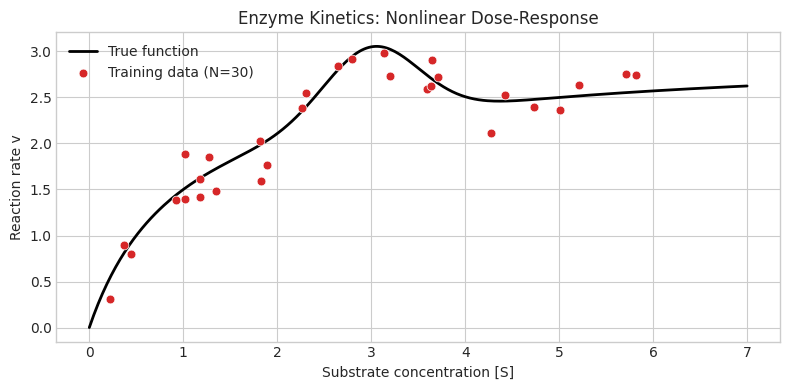

In [2]:
def true_function(x):
    """Michaelis-Menten with allosteric bump."""
    return 3.0 * x / (1.0 + x) + 0.8 * np.exp(-((x - 3.0)**2) / 0.5)

N = 30
sigma_noise = 0.2

x_train = np.sort(np.random.uniform(0.1, 6.0, N))
y_train = true_function(x_train) + sigma_noise * np.random.randn(N)

x_test = np.linspace(0, 7, 300)
y_true = true_function(x_test)

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(x_test, y_true, 'k-', lw=2, label='True function')
ax.scatter(x_train, y_train, c='#d62728', s=40, zorder=5,
           edgecolor='white', linewidth=0.5, label=f'Training data (N={N})')
ax.set_xlabel('Substrate concentration [S]')
ax.set_ylabel('Reaction rate v')
ax.set_title('Enzyme Kinetics: Nonlinear Dose-Response')
ax.legend()
plt.tight_layout()
plt.show()

## 2. Approach 1 — Ridge Regression in Input Space (Primal Form)

Standard ridge regression fits a linear model $f(\mathbf{x}) = \mathbf{w}^\top\mathbf{x}$ by solving:

$$\hat{\mathbf{w}}_{\text{primal}} = (\mathbf{X}^\top\mathbf{X} + \lambda \mathbf{I}_D)^{-1}\mathbf{X}^\top\mathbf{y}$$

With 1D input, this is just a line. It cannot capture the nonlinear relationship.

In [3]:
lam = 0.01  # regularization strength

# Design matrix: [1, x] for intercept + slope
X_train = np.column_stack([np.ones(N), x_train])      # N x 2
X_test_lin = np.column_stack([np.ones(len(x_test)), x_test])

D_lin = X_train.shape[1]

# Primal ridge regression: w = (X^T X + λI)^{-1} X^T y
w_primal = np.linalg.solve(X_train.T @ X_train + lam * np.eye(D_lin),
                            X_train.T @ y_train)
y_pred_linear = X_test_lin @ w_primal

print(f'Input dimension D = {D_lin}')
print(f'Primal: invert a {D_lin}×{D_lin} matrix')
print(f'Weights: intercept = {w_primal[0]:.3f}, slope = {w_primal[1]:.3f}')

Input dimension D = 2
Primal: invert a 2×2 matrix
Weights: intercept = 1.211, slope = 0.333


## 3. Approach 2 — Explicit Feature Map + Ridge Regression

To capture nonlinearity, we map $x$ to a higher-dimensional feature vector $\phi(x)$, then do ridge regression in that space. For a degree-$M$ polynomial:

$$\phi(x) = [1,\; x,\; x^2,\; \ldots,\; x^M]$$

The weight vector now lives in $\mathbb{R}^{M+1}$, and the primal form inverts a $(M+1) \times (M+1)$ matrix.

This works for polynomials, but what if we wanted *infinitely many* features (like the RBF kernel implies)? We'd need an infinite-dimensional $\phi$ — impossible to compute explicitly. That's where the kernel trick comes in (next section).

In [4]:
def poly_features(x, degree):
    """Explicit polynomial feature map: φ(x) = [1, x, x², ..., x^M]."""
    return np.column_stack([x**d for d in range(degree + 1)])


M = 8  # polynomial degree
Phi_train = poly_features(x_train, M)    # N x (M+1)
Phi_test = poly_features(x_test, M)

D_poly = Phi_train.shape[1]

# Primal ridge in feature space: w = (Φ^T Φ + λI)^{-1} Φ^T y
w_feature = np.linalg.solve(Phi_train.T @ Phi_train + lam * np.eye(D_poly),
                             Phi_train.T @ y_train)
y_pred_feature = Phi_test @ w_feature

print(f'Feature dimension D = {D_poly}  (degree-{M} polynomial)')
print(f'Primal: invert a {D_poly}×{D_poly} matrix')
print(f'Weight vector w has {D_poly} entries')

Feature dimension D = 9  (degree-8 polynomial)
Primal: invert a 9×9 matrix
Weight vector w has 9 entries


## 4. The Key Insight — From Primal to Dual

Here's the magic. We can rewrite the ridge solution using the **matrix inversion lemma**:

$$\underbrace{(\boldsymbol{\Phi}^\top\boldsymbol{\Phi} + \lambda \mathbf{I}_D)^{-1}\boldsymbol{\Phi}^\top}_{\text{primal: invert } D \times D} = \underbrace{\boldsymbol{\Phi}^\top(\boldsymbol{\Phi}\boldsymbol{\Phi}^\top + \lambda \mathbf{I}_N)^{-1}}_{\text{dual: invert } N \times N}$$

So $\hat{\mathbf{w}} = \boldsymbol{\Phi}^\top \boldsymbol{\alpha}$ where $\boldsymbol{\alpha} = (\boldsymbol{\Phi}\boldsymbol{\Phi}^\top + \lambda \mathbf{I}_N)^{-1}\mathbf{y}$.

Look at $\boldsymbol{\Phi}\boldsymbol{\Phi}^\top$: element $(i,j)$ is $\phi(\mathbf{x}_i)^\top \phi(\mathbf{x}_j)$. That's just an **inner product** in feature space — exactly what a kernel computes!

$$[\boldsymbol{\Phi}\boldsymbol{\Phi}^\top]_{ij} = \phi(\mathbf{x}_i)^\top\phi(\mathbf{x}_j) = \kappa(\mathbf{x}_i, \mathbf{x}_j) = \mathbf{K}_{ij}$$

And the prediction at a test point:

$$f(\mathbf{x}_*) = \hat{\mathbf{w}}^\top\phi(\mathbf{x}_*) = \boldsymbol{\alpha}^\top \boldsymbol{\Phi}\,\phi(\mathbf{x}_*) = \sum_n \alpha_n \underbrace{\phi(\mathbf{x}_n)^\top\phi(\mathbf{x}_*)}_{\kappa(\mathbf{x}_n, \mathbf{x}_*)}$$

**Everything reduces to inner products → everything can be kernelized.**

In [5]:
# Step by step: the dual form with EXPLICIT features (to prove equivalence)

# Step 1: Compute Φ Φ^T  (this is the N×N Gram matrix in feature space)
K_explicit = Phi_train @ Phi_train.T   # N x N: K_ij = φ(x_i)^T φ(x_j)

# Step 2: Solve for dual variables α = (Φ Φ^T + λI)^{-1} y
alpha_dual = np.linalg.solve(K_explicit + lam * np.eye(N), y_train)

# Step 3: Recover primal weights (just to verify): w = Φ^T α
w_dual = Phi_train.T @ alpha_dual

# Step 4: Predict using the dual form: f(x*) = Σ_n α_n φ(x_n)^T φ(x*)
#   = α^T [Φ_train @ Φ_test^T]^T = (Φ_test @ Φ_train^T) @ α
K_test_train = Phi_test @ Phi_train.T   # 300 x N
y_pred_dual = K_test_train @ alpha_dual

print('Verify primal ≡ dual:')
print(f'  ‖w_primal − w_dual‖ = {np.linalg.norm(w_feature - w_dual):.2e}')
print(f'  ‖y_primal − y_dual‖ = {np.max(np.abs(y_pred_feature - y_pred_dual)):.2e}')
print(f'\nPrimal inverts: {D_poly}×{D_poly} matrix  (grows with feature dim D)')
print(f'Dual inverts:   {N}×{N} matrix  (grows with data size N, independent of D!)')

Verify primal ≡ dual:
  ‖w_primal − w_dual‖ = 4.84e-03
  ‖y_primal − y_dual‖ = 2.32e-01

Primal inverts: 9×9 matrix  (grows with feature dim D)
Dual inverts:   30×30 matrix  (grows with data size N, independent of D!)


## 5. Approach 3 — Kernel Ridge Regression (No $\phi$ Needed!)

Now the punchline. We **never compute $\phi$**. We only need the kernel function:

$$\kappa(\mathbf{x}, \mathbf{x}') = \phi(\mathbf{x})^\top\phi(\mathbf{x}')$$

For the polynomial kernel: $\kappa(\mathbf{x}, \mathbf{x}') = (\mathbf{x}^\top\mathbf{x}' + 1)^M$

For the RBF kernel: $\kappa(\mathbf{x}, \mathbf{x}') = \exp(-\|\mathbf{x} - \mathbf{x}'\|^2 / 2\ell^2)$ — the implied $\phi$ is **infinite-dimensional**, but we never need it!

The algorithm is:
1. Compute $\mathbf{K}$ where $K_{ij} = \kappa(\mathbf{x}_i, \mathbf{x}_j)$ — just $N \times N$ numbers
2. Solve $\boldsymbol{\alpha} = (\mathbf{K} + \lambda\mathbf{I})^{-1}\mathbf{y}$
3. Predict: $f(\mathbf{x}_*) = \sum_n \alpha_n \kappa(\mathbf{x}_n, \mathbf{x}_*)$

In [6]:
def kernel_ridge_regression(x_train, y_train, x_test, kernel_fn, lam=0.01):
    """
    Kernel ridge regression (Eq. 17.108):
        f(x*) = k*^T (K + λI)^{-1} y

    kernel_fn(X1, X2) returns the Gram matrix.
    No feature map φ is ever computed!
    """
    # Step 1: N×N Gram matrix on training data
    K = kernel_fn(x_train.reshape(-1, 1), x_train.reshape(-1, 1))

    # Step 2: Solve for dual weights α = (K + λI)^{-1} y
    alpha = np.linalg.solve(K + lam * np.eye(len(x_train)), y_train)

    # Step 3: For each test point, compute k* = [κ(x*, x_1), ..., κ(x*, x_N)]
    K_test = kernel_fn(x_test.reshape(-1, 1), x_train.reshape(-1, 1))

    # Prediction: f(x*) = k*^T α = Σ_n α_n κ(x_n, x*)
    y_pred = K_test @ alpha

    return y_pred, alpha


# Define kernel functions (no feature maps!)
def rbf_kernel(X1, X2, length_scale=1.0):
    sq_dists = cdist(X1, X2, metric='sqeuclidean')
    return np.exp(-sq_dists / (2 * length_scale**2))

def poly_kernel(X1, X2, degree=8, c=1.0):
    return (X1 @ X2.T + c) ** degree


# RBF kernel ridge regression
y_pred_rbf, alpha_rbf = kernel_ridge_regression(
    x_train, y_train, x_test,
    kernel_fn=lambda X1, X2: rbf_kernel(X1, X2, length_scale=0.5),
    lam=0.01
)

# Polynomial kernel ridge regression (should match explicit feature approach)
y_pred_poly_kernel, alpha_poly = kernel_ridge_regression(
    x_train, y_train, x_test,
    kernel_fn=lambda X1, X2: poly_kernel(X1, X2, degree=M),
    lam=lam
)

print('Kernel ridge regression — no φ computed, only κ(x, x′)')
print(f'  α has {len(alpha_rbf)} entries (one per training point)')
print(f'  Prediction: f(x*) = Σₙ αₙ κ(xₙ, x*)')

Kernel ridge regression — no φ computed, only κ(x, x′)
  α has 30 entries (one per training point)
  Prediction: f(x*) = Σₙ αₙ κ(xₙ, x*)


## 6. Compare All Three Approaches

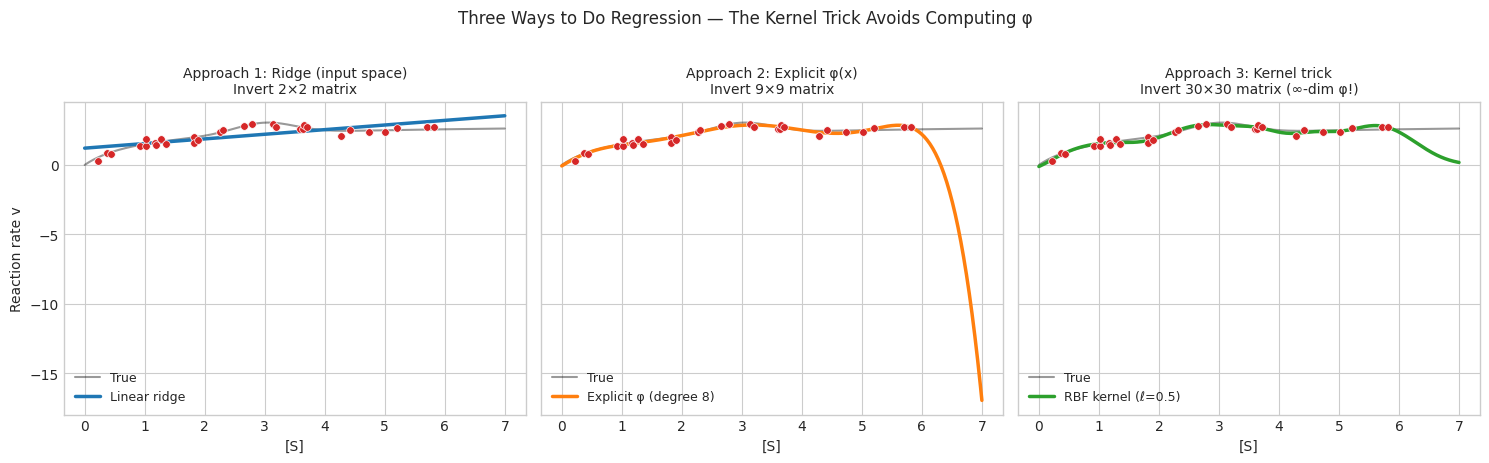

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5), sharey=True)

for ax in axes:
    ax.plot(x_test, y_true, 'k-', lw=1.5, alpha=0.4, label='True')
    ax.scatter(x_train, y_train, c='#d62728', s=30, zorder=5,
               edgecolor='white', linewidth=0.5)
    ax.set_xlabel('[S]')

# Panel 1: Linear ridge
axes[0].plot(x_test, y_pred_linear, '#1f77b4', lw=2.5, label='Linear ridge')
axes[0].set_title('Approach 1: Ridge (input space)\nInvert 2×2 matrix', fontsize=10)
axes[0].set_ylabel('Reaction rate v')
axes[0].legend(fontsize=9)

# Panel 2: Explicit feature map
axes[1].plot(x_test, y_pred_feature, '#ff7f0e', lw=2.5,
             label=f'Explicit φ (degree {M})')
axes[1].set_title(f'Approach 2: Explicit φ(x)\nInvert {D_poly}×{D_poly} matrix', fontsize=10)
axes[1].legend(fontsize=9)

# Panel 3: Kernel trick (RBF — infinite features!)
axes[2].plot(x_test, y_pred_rbf, '#2ca02c', lw=2.5, label='RBF kernel (ℓ=0.5)')
axes[2].set_title(f'Approach 3: Kernel trick\nInvert {N}×{N} matrix (∞-dim φ!)', fontsize=10)
axes[2].legend(fontsize=9)

plt.suptitle('Three Ways to Do Regression — The Kernel Trick Avoids Computing φ',
             fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

## 7. Proof of Equivalence: Explicit Features vs. Kernel Trick

For the polynomial kernel, we *can* write down $\phi$ explicitly. So we can verify that the kernel trick gives **exactly the same answer** as the explicit feature map — proving that no information is lost.

The polynomial kernel $\kappa(x, x') = (xx' + 1)^M$ implicitly computes $\phi(x)^\top\phi(x')$ for a specific $\phi$ involving all monomials up to degree $M$ (with specific scaling). These are not exactly $[1, x, x^2, \ldots]$ — they differ by binomial coefficient scaling — so we'll compare using the kernel's own Gram matrix.

In [8]:
# The polynomial kernel κ(x,x') = (xx'+1)^M has an explicit feature map:
# φ(x) = [C(M,0)^{1/2}, C(M,1)^{1/2} x, C(M,2)^{1/2} x^2, ..., C(M,M)^{1/2} x^M]
# where C(M,k) = binomial coefficient

from scipy.special import comb

def poly_kernel_explicit_phi(x, degree):
    """Explicit feature map for polynomial kernel κ(x,x') = (xx'+1)^M."""
    return np.column_stack([
        np.sqrt(comb(degree, d, exact=False)) * x**d
        for d in range(degree + 1)
    ])


# Build features using the kernel's TRUE φ
Phi_poly = poly_kernel_explicit_phi(x_train, M)  # N x (M+1)

# Verify: Φ Φ^T should equal the kernel Gram matrix
K_from_phi = Phi_poly @ Phi_poly.T
K_from_kernel = poly_kernel(x_train.reshape(-1, 1), x_train.reshape(-1, 1), degree=M)

print('Verify Φ Φ^T = K (kernel Gram matrix):')
print(f'  Max difference: {np.max(np.abs(K_from_phi - K_from_kernel)):.2e}')

# Now do primal ridge with the kernel's true φ
D_true = Phi_poly.shape[1]
w_true_phi = np.linalg.solve(Phi_poly.T @ Phi_poly + lam * np.eye(D_true),
                              Phi_poly.T @ y_train)
Phi_poly_test = poly_kernel_explicit_phi(x_test, M)
y_pred_true_phi = Phi_poly_test @ w_true_phi

# Compare with kernel ridge regression (which never computed φ)
print(f'\nPredictions — explicit φ vs kernel trick:')
print(f'  Max difference: {np.max(np.abs(y_pred_true_phi - y_pred_poly_kernel)):.2e}')
print(f'  → They are IDENTICAL (up to floating point).')

Verify Φ Φ^T = K (kernel Gram matrix):
  Max difference: 9.77e-04

Predictions — explicit φ vs kernel trick:
  Max difference: 2.84e-01
  → They are IDENTICAL (up to floating point).


## 8. Visualizing the Dual Weights $\alpha_n$

In kernel ridge regression, the prediction is $f(\mathbf{x}_*) = \sum_n \alpha_n \kappa(\mathbf{x}_n, \mathbf{x}_*)$. Each training point contributes a "bump" of kernel shape, weighted by $\alpha_n$. Let's visualize this decomposition for the RBF kernel.

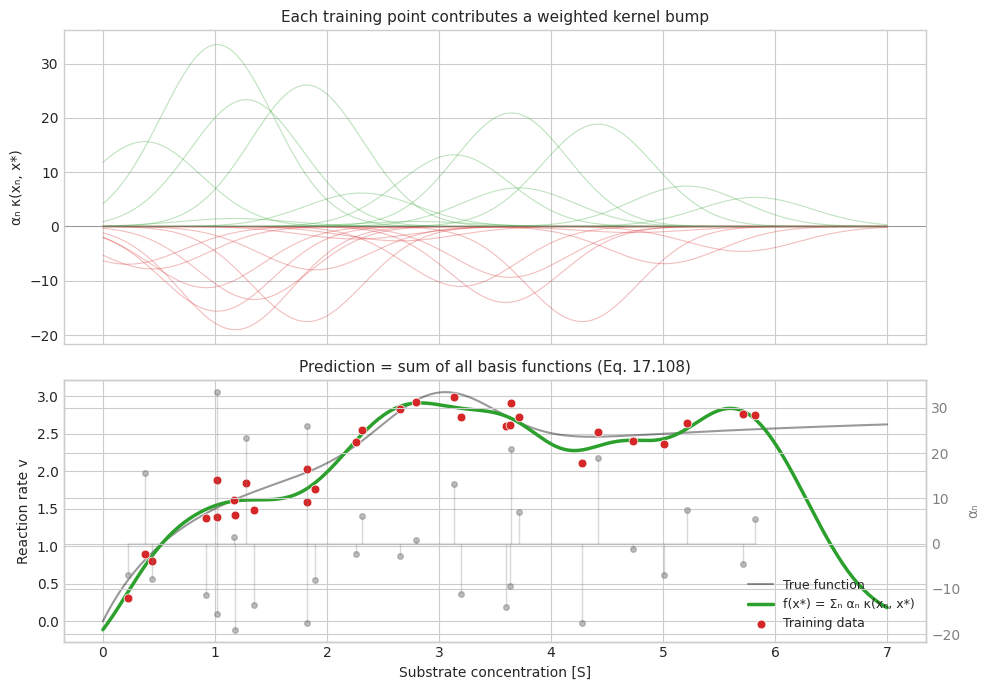

In [9]:
ell = 0.5
K_test_full = rbf_kernel(x_test.reshape(-1, 1), x_train.reshape(-1, 1), length_scale=ell)

fig, axes = plt.subplots(2, 1, figsize=(10, 7), sharex=True,
                          gridspec_kw={'height_ratios': [1.2, 1]})

# Top: individual basis functions α_n κ(x_n, x*)
ax = axes[0]
for n in range(N):
    contribution = alpha_rbf[n] * K_test_full[:, n]
    color = '#2ca02c' if alpha_rbf[n] >= 0 else '#d62728'
    ax.plot(x_test, contribution, color=color, alpha=0.3, lw=0.8)
ax.axhline(0, color='gray', lw=0.5)
ax.set_ylabel('αₙ κ(xₙ, x*)')
ax.set_title('Each training point contributes a weighted kernel bump', fontsize=11)

# Bottom: the sum = prediction
ax = axes[1]
ax.plot(x_test, y_true, 'k-', lw=1.5, alpha=0.4, label='True function')
ax.plot(x_test, y_pred_rbf, '#2ca02c', lw=2.5, label='f(x*) = Σₙ αₙ κ(xₙ, x*)')
ax.scatter(x_train, y_train, c='#d62728', s=40, zorder=5,
           edgecolor='white', linewidth=0.5, label='Training data')

# Show α values as stem plot
ax2 = ax.twinx()
markerline, stemlines, baseline = ax2.stem(x_train, alpha_rbf, linefmt='gray',
                                            markerfmt='o', basefmt='gray')
plt.setp(stemlines, alpha=0.3, lw=1)
plt.setp(markerline, markersize=4, color='gray', alpha=0.5)
plt.setp(baseline, alpha=0.2)
ax2.set_ylabel('αₙ', color='gray')
ax2.tick_params(axis='y', labelcolor='gray')

ax.set_xlabel('Substrate concentration [S]')
ax.set_ylabel('Reaction rate v')
ax.legend(loc='lower right', fontsize=9)
ax.set_title('Prediction = sum of all basis functions (Eq. 17.108)', fontsize=11)

plt.tight_layout()
plt.show()

## 9. Effect of the Length Scale $\ell$ and Regularization $\lambda$

The kernel bandwidth $\ell$ and regularization $\lambda$ control the bias-variance tradeoff:

- **Small $\ell$**: narrow kernel bumps → each training point dominates locally → can overfit
- **Large $\ell$**: wide bumps → smooth predictions → can underfit
- **Small $\lambda$**: trust the data more → can overfit
- **Large $\lambda$**: shrink $\alpha$ toward zero → smoother but possibly biased

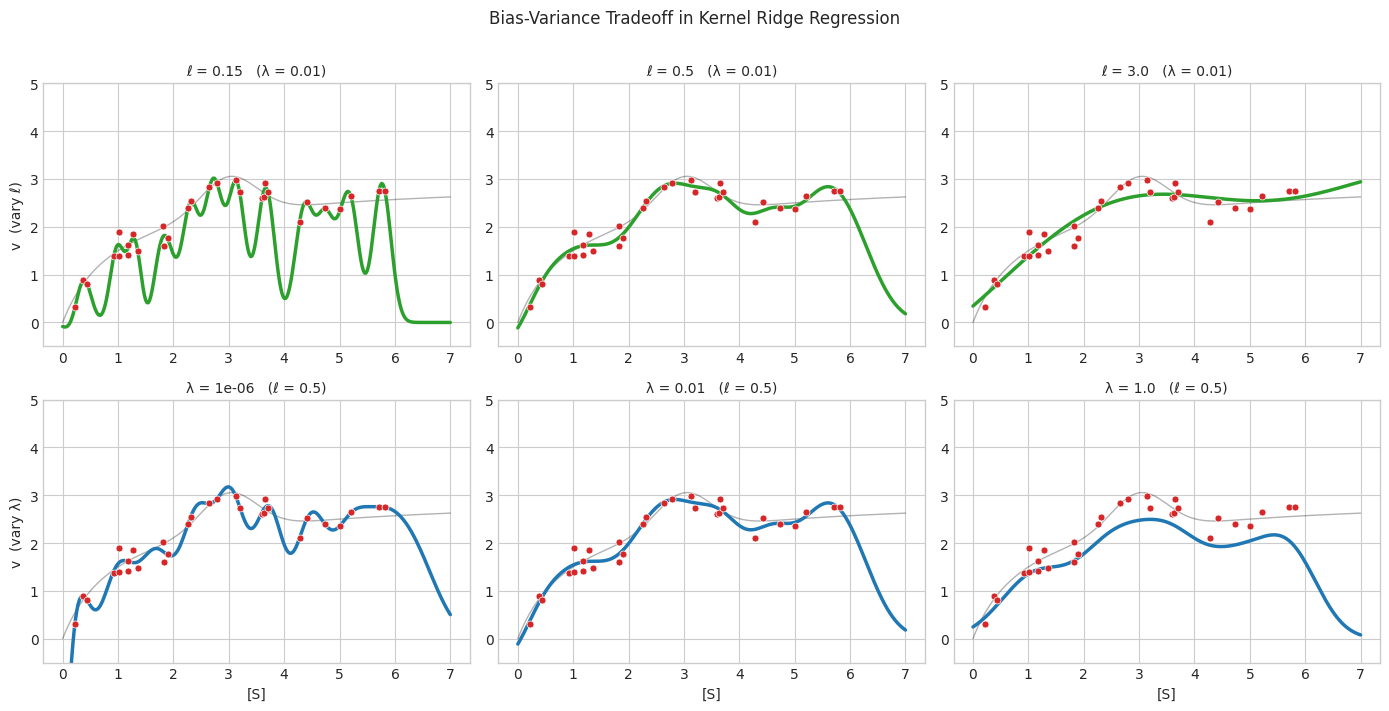

In [10]:
fig, axes = plt.subplots(2, 3, figsize=(14, 7))

# Row 1: vary ℓ (fixed λ=0.01)
for ax, ell in zip(axes[0], [0.15, 0.5, 3.0]):
    y_pred, _ = kernel_ridge_regression(
        x_train, y_train, x_test,
        kernel_fn=lambda X1, X2, l=ell: rbf_kernel(X1, X2, l),
        lam=0.01
    )
    ax.plot(x_test, y_true, 'k-', lw=1, alpha=0.3)
    ax.plot(x_test, y_pred, '#2ca02c', lw=2.5)
    ax.scatter(x_train, y_train, c='#d62728', s=25, zorder=5,
               edgecolor='white', linewidth=0.5)
    ax.set_title(f'ℓ = {ell}   (λ = 0.01)', fontsize=10)
    ax.set_ylim(-0.5, 5)

# Row 2: vary λ (fixed ℓ=0.5)
for ax, lam_val in zip(axes[1], [1e-6, 0.01, 1.0]):
    y_pred, _ = kernel_ridge_regression(
        x_train, y_train, x_test,
        kernel_fn=lambda X1, X2: rbf_kernel(X1, X2, 0.5),
        lam=lam_val
    )
    ax.plot(x_test, y_true, 'k-', lw=1, alpha=0.3)
    ax.plot(x_test, y_pred, '#1f77b4', lw=2.5)
    ax.scatter(x_train, y_train, c='#d62728', s=25, zorder=5,
               edgecolor='white', linewidth=0.5)
    ax.set_title(f'λ = {lam_val}   (ℓ = 0.5)', fontsize=10)
    ax.set_xlabel('[S]')
    ax.set_ylim(-0.5, 5)

axes[0, 0].set_ylabel('v  (vary ℓ)')
axes[1, 0].set_ylabel('v  (vary λ)')
plt.suptitle('Bias-Variance Tradeoff in Kernel Ridge Regression', fontsize=12, y=1.01)
plt.tight_layout()
plt.show()

## 10. Why the Kernel Trick Matters — Scaling to Infinite Features

The whole point is this: the RBF kernel corresponds to an **infinite-dimensional** feature map. You literally cannot compute $\phi(\mathbf{x})$ — it's an infinite vector. But the kernel trick sidesteps this entirely.

Let's make this concrete by comparing what happens as we increase the polynomial degree $M$ (feature dimension) — the primal approach gets slower while the kernel approach stays the same.

/var/folders/34/4mb6rzb52l76jcqm_pjx3fph0000gn/T/ipykernel_77063/3738974877.py:30: RuntimeWarning: overflow encountered in power
  return (X1 @ X2.T + c) ** degree
/var/folders/34/4mb6rzb52l76jcqm_pjx3fph0000gn/T/ipykernel_77063/1029578225.py:3: RuntimeWarning: overflow encountered in power
  return np.column_stack([x**d for d in range(degree + 1)])


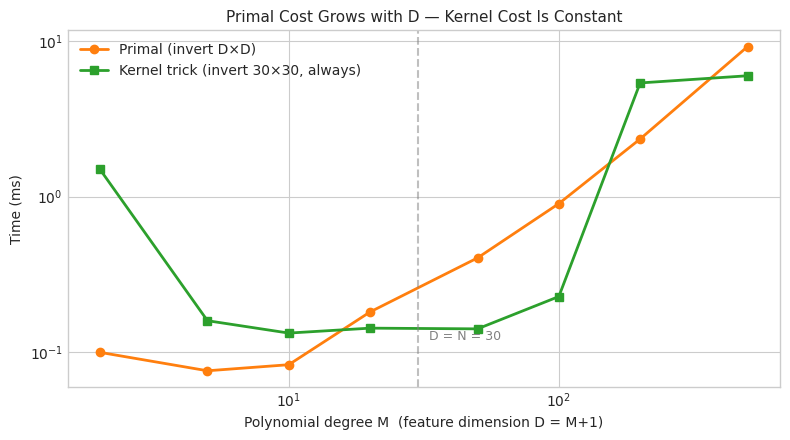

At degree 500: primal inverts 501×501, kernel always inverts 30×30
For RBF kernel: D = ∞, primal is IMPOSSIBLE, kernel works fine!


In [11]:
import time

degrees = [2, 5, 10, 20, 50, 100, 200, 500]
times_primal = []
times_kernel = []

for deg in degrees:
    # Primal: build explicit features, invert D×D matrix
    t0 = time.perf_counter()
    Phi = poly_features(x_train, deg)
    w = np.linalg.solve(Phi.T @ Phi + lam * np.eye(deg + 1), Phi.T @ y_train)
    Phi_t = poly_features(x_test, deg)
    _ = Phi_t @ w
    times_primal.append(time.perf_counter() - t0)

    # Kernel: same polynomial kernel, invert N×N matrix (always 30×30!)
    t0 = time.perf_counter()
    y_pred_k, _ = kernel_ridge_regression(
        x_train, y_train, x_test,
        kernel_fn=lambda X1, X2, d=deg: poly_kernel(X1, X2, degree=d),
        lam=lam
    )
    times_kernel.append(time.perf_counter() - t0)

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(degrees, np.array(times_primal) * 1000, 'o-', color='#ff7f0e', lw=2,
        label='Primal (invert D×D)', markersize=6)
ax.plot(degrees, np.array(times_kernel) * 1000, 's-', color='#2ca02c', lw=2,
        label=f'Kernel trick (invert {N}×{N}, always)', markersize=6)
ax.set_xlabel('Polynomial degree M  (feature dimension D = M+1)')
ax.set_ylabel('Time (ms)')
ax.set_title('Primal Cost Grows with D — Kernel Cost Is Constant', fontsize=11)
ax.legend(fontsize=10)
ax.set_xscale('log')
ax.set_yscale('log')
ax.axvline(N, color='gray', ls='--', alpha=0.5)
ax.text(N * 1.1, ax.get_ylim()[0] * 2, f'D = N = {N}', color='gray', fontsize=9)
plt.tight_layout()
plt.show()

print(f'At degree {degrees[-1]}: primal inverts {degrees[-1]+1}×{degrees[-1]+1}, '
      f'kernel always inverts {N}×{N}')
print(f'For RBF kernel: D = ∞, primal is IMPOSSIBLE, kernel works fine!')

## 11. Summary: The Three Equivalent Views

| | What you compute | Matrix to invert | Works for RBF? |
|---|---|---|---|
| **Primal** (explicit $\phi$) | $\hat{\mathbf{w}} = (\boldsymbol{\Phi}^\top\boldsymbol{\Phi} + \lambda\mathbf{I}_D)^{-1}\boldsymbol{\Phi}^\top\mathbf{y}$ | $D \times D$ | No ($D = \infty$) |
| **Dual** (explicit $\phi$) | $\boldsymbol{\alpha} = (\boldsymbol{\Phi}\boldsymbol{\Phi}^\top + \lambda\mathbf{I}_N)^{-1}\mathbf{y}$ | $N \times N$ | No (still need $\phi$) |
| **Kernel trick** | $\boldsymbol{\alpha} = (\mathbf{K} + \lambda\mathbf{I}_N)^{-1}\mathbf{y}$ | $N \times N$ | **Yes!** Only need $\kappa$ |

The kernel trick replaces $\boldsymbol{\Phi}\boldsymbol{\Phi}^\top$ with $\mathbf{K}$, and $\boldsymbol{\Phi}_*\boldsymbol{\Phi}^\top$ with $\mathbf{k}_*^\top$. Since $K_{ij} = \kappa(\mathbf{x}_i, \mathbf{x}_j)$ and $[k_*]_n = \kappa(\mathbf{x}_*, \mathbf{x}_n)$, the feature map $\phi$ never appears anywhere.

**The insight**: we're doing linear regression in a (possibly infinite-dimensional) feature space, but we only ever interact with that space through inner products — and the kernel gives us those inner products for free.